In [ ]:
%pip install tensorpac

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mne
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings

from tensorpac import Pac

warnings.filterwarnings('ignore')

### Merging tables

In [2]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

In [3]:
# Shows the first 5 rows of the table with all columns
display(df_complete.head())

print(f"\nTotal patients with pain scores: {df_complete.shape[0]}")
print(f"Total merged columns: {df_complete.shape[1]}")

,ID,Pain Score (Actual Pain of Brief Pain Inventory),Age,Gender,Etiology of NP*,Time with NP,Medical treatment for NP,Since when have you use the previous medication?,Have you had any medical procedures to control the pain?,Do you go regularly to phsychological or emotional counseling sessions for your pain?,...,Please write your main area of pain,Does your pain radiate to other regions of your body?,"If the answer is yes, please write the direction in which it irradiates as explicitly as possible","Do you suffer from a burning sensation (e.g., stinging nettles) in the marked areas?",Do you have a tingling or prickling sensation in the area of your pain (like crawling ants or electrical tingling)?,"Is light touching (clothing, a blanket) in this area painful?","Do you have sudden pain attacks in the area of your pain, like electric shocks?",Is cold or heat (bath water) in this area occasionally painful?,Do you suffer from a sensation of numbness in the areas that you marked?,"Does slight pressure in this area, e.g., with a finger, trigger pain?"
0,0,7.0,25.0,F,Central Nervous System Disorder (CRPS or Lyme),More than 2 years,"Pregabalin, amitriptyline",More than a year ago,Nerve blocks and infusions*,Yes,...,Soles of feet and palms of hands,Yes,"From the feet to lower back, from the hands to...",Strongly,Strongly,Strongly,Very Strongly,Very Strongly,Strongly,Moderately
1,1,4.0,57.0,F,Diabetes,More than 2 years,Tramadol,More than a month ago,NaN,No,...,Sole of feet,No,NaN,Very Strongly,Strongly,Strongly,Strongly,Strongly,Strongly,Strongly
2,2,3.0,20.0,F,Peripheral neuropathy,More than 2 years,Keterolac,More than a year ago,NaN,No,...,Wrist and hand,Yes,From the wrist to the fingers,Never,Moderately,Never,Moderately,Strongly,Very Strongly,Slightly
3,3,8.0,34.0,F,Spinal cord or nerve root injury,More than 2 years,Tramadol,More than a year ago,Physiotherapy,No,...,Lower back,No,NaN,Strongly,Moderately,Never,Never,Moderately,Never,Very Strongly
4,4,5.0,77.0,M,Spinal cord or nerve root injury,More than 2 years,NaN,NaN,NaN,No,...,"Legs, back, neck and head",Yes,To the limbs,Never,Strongly,Never,Strongly,Never,Strongly,Strongly



Total patients with pain scores: 36
Total merged columns: 35


In [4]:
csv_filename = 'eeg_model_results_eo_ec.csv'
current_condition = 'Eyes Closed'

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"Existing table loaded with {len(df_results)} records")
else:
    # Defining the columns
    columns = ['Model', 'Condition', 'Accuracy', 'AUC_ROC', 'F1_Score']
    df_results = pd.DataFrame(columns=columns)
    print("New table created successfully")

if 'model_results' not in locals():
    model_results = {}

New table created successfully


In [5]:
# Potência Absoluta (1° Feature)
bands = {
    'Delta': (0.1, 4), # nova banda
    'Theta': (4, 8),
    'Low_Alpha': (8, 10), # deixar a alpha dividida
    'High_Alpha': (10, 13),
    'Low_Beta': (13, 17),
    'High_Beta': (18, 30),
    'Low_Gamma': (30, 50), # divisão de beta e gamma (além da expansão dos antigos 40Hz)
    'High_Gamma': (50, 100)
}

asymmetry_pairs = {
    'Fp1': 'Fp2',
    'F3': 'F4',
    'C3': 'C4',
    'P3': 'P4',
    'O1': 'O2',
    'F7': 'F8',
    'T7': 'T8',
    'P7': 'P8'
}

X_features = []
y_labels = []
feature_names = []
model_results = {}
eeg_folder = './cleaned' 

pac_pairs = [ # novos pares
    ('Theta', 'Low_Gamma'),
    ('Theta', 'High_Gamma'),
    ('Low_Alpha', 'Low_Gamma'),
    ('High_Alpha', 'High_Gamma'),
    ('Low_Beta', 'Low_Gamma'),
    ('High_Beta', 'High_Gamma')
]

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

In [6]:
def compute_pac_mi(data_2d, sfreq, f_phase, f_amp):
    """
    Calcula o Acoplamento Fase-Amplitude (PAC) usando a classe principal do Tensorpac.
    """
    # Define a configuração do PAC usando a tupla idpac=(2, 0, 0):
    # 2 - Usa o 'Modulation Index' (Tort et al., 2010)
    # 0 - Sem cálculo de dados substitutos (surrogates) para ser mais rápido
    # 0 - Sem normalização
    p = Pac(idpac=(2, 0, 0), 
            f_pha=[f_phase[0], f_phase[1]], # Limites da banda de Fase
            f_amp=[f_amp[0], f_amp[1]], # Limites da banda de Amplitude
            dcomplex='hilbert', # Usa Hilbert para extração
            verbose=False)

    # (n_amp, n_pha, n_epochs)
    xpac = p.filterfit(sfreq, data_2d, n_jobs=1)
    
    # Extrai a média do PAC entre todas as epochs processadas
    return np.mean(xpac[0, 0, :])

Comodulograma PAC para Paciente 0 - Canal P8


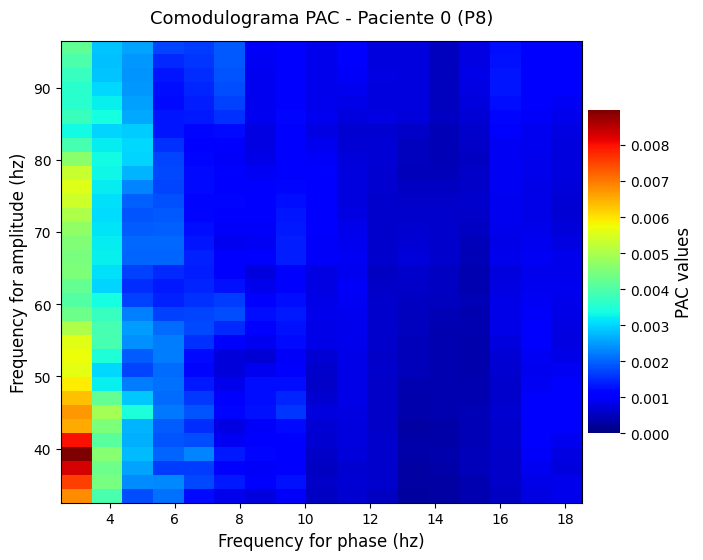

Processamento do paciente 0 finalizado.
Processamento do paciente 1 finalizado.
Processamento do paciente 2 finalizado.
Processamento do paciente 3 finalizado.
Processamento do paciente 4 finalizado.
Processamento do paciente 5 finalizado.
Processamento do paciente 6 finalizado.
Processamento do paciente 7 finalizado.
Processamento do paciente 8 finalizado.
Processamento do paciente 9 finalizado.
Processamento do paciente 10 finalizado.
Processamento do paciente 11 finalizado.
Processamento do paciente 13 finalizado.
Processamento do paciente 15 finalizado.
Processamento do paciente 16 finalizado.
Processamento do paciente 18 finalizado.
Processamento do paciente 19 finalizado.
Processamento do paciente 20 finalizado.
Processamento do paciente 21 finalizado.
Processamento do paciente 22 finalizado.
Processamento do paciente 23 finalizado.
Processamento do paciente 24 finalizado.
Processamento do paciente 25 finalizado.
Processamento do paciente 26 finalizado.
Processamento do paciente 

In [7]:
# PAC, Assimetria pelo log das potências e do PAC

comodulograma_gerado = False

for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID'])) 
    pain_score = float(row['Actual Pain']) 
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_eo_epochs.fif")
    
    if os.path.exists(path):
        try:
            # Carrega o sinal processado
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            all_channels = epochs.ch_names
            sfreq = epochs.info['sfreq']

            epochs_data = epochs.get_data()
            
            # Densidade Espectral usando Welch
            psd = epochs.compute_psd(fmin=0.1, fmax=100, method='welch', verbose=False) # PSD
            psd_data, freqs = psd.get_data(return_freqs=True)
            psd_data = psd_data.mean(axis=0) # Média ao longo das epochs (axis=0)
            
            patient_features = []
            channel_power = {}
            channel_pac = {}
            temp_names = [] 

            for channel in target_channels:
                if channel in all_channels:
                    i = all_channels.index(channel)
                    channel_epochs = epochs_data[:, i, :]

                    if not comodulograma_gerado and channel == 'P8':
                        print(f"Comodulograma PAC para Paciente {patient_id} - Canal {channel}")
                        
                        # Para gerar o mapa 2D, definimos limites contínuos (start, stop, width, step)
                        # Fase: 2 a 20 Hz. Amplitude: 30 a 100 Hz.
                        p_plot = Pac(idpac=(2, 0, 0), 
                                     f_pha=(2, 20, 1, 1), 
                                     f_amp=(30, 100, 5, 2), 
                                     dcomplex='hilbert', 
                                     verbose=False)
                        
                        xpac_plot = p_plot.filterfit(sfreq, channel_epochs, n_jobs=1)
                        
                        plt.figure(figsize=(8, 6))
                        
                        p_plot.comodulogram(xpac_plot.mean(axis=-1), 
                                            title=f'Comodulograma PAC - Paciente {patient_id} ({channel})', 
                                            cmap='jet', 
                                            vmin=0)

                        nome_imagem = f"comodulograma_ID{patient_id}_{channel}.png"
                        plt.savefig(nome_imagem, dpi=300, bbox_inches='tight')

                        plt.show()

                        comodulograma_gerado = True
                    
                    # Potência por Banda
                    channel_power[channel] = {}
                    for band_name, (fmin, fmax) in bands.items():
                        band_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                        power = np.sum(psd_data[i, band_idx])
                        channel_power[channel][band_name] = power
                        patient_features.append(power)
                        if not feature_names: temp_names.append(f"Pow_{channel}_{band_name}")
                
                    # Acoplamento PAC
                    channel_pac[channel] = {}
                    for (f_phase, f_amp) in pac_pairs:
                        mi = compute_pac_mi(channel_epochs, sfreq, bands[f_phase], bands[f_amp])
                        pac_name = f"{f_phase}-{f_amp}"
                        channel_pac[channel][pac_name] = mi
                        patient_features.append(mi)
                        if not feature_names: temp_names.append(f"PAC_{channel}_{pac_name}")
                        
                else:
                    # Preenchimento em caso de canal ausente
                    for band_name in bands.keys():
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Pow_{channel}_{band_name}")
                    for (f_phase, f_amp) in pac_pairs:
                        patient_features.append(np.nan)
                        pac_name = f"{f_phase}-{f_amp}"
                        if not feature_names: temp_names.append(f"PAC_{channel}_{pac_name}")

            # LOOP DE ASSIMETRIA
            epsilon = 1e-10 # Evita log(0) ou divisão por zero
            
            for left_channel, right_channel in asymmetry_pairs.items():
                if left_channel in channel_power and right_channel in channel_power:
                    
                    # Assimetria Logarítmica de Potência
                    for band_name in bands.keys():
                        p_left = channel_power[left_channel][band_name]
                        p_right = channel_power[right_channel][band_name]
                        
                        asymmetry = np.log(max(p_right, epsilon) / max(p_left, epsilon))
                        patient_features.append(asymmetry)
                        if not feature_names: temp_names.append(f"Asym_Pow_{left_channel}-{right_channel}_{band_name}")
                    
                    # Assimetria Logarítmica do PAC
                    for (f_phase, f_amp) in pac_pairs:
                        pac_name = f"{f_phase}-{f_amp}"
                        p_left_pac = channel_pac[left_channel][pac_name]
                        p_right_pac = channel_pac[right_channel][pac_name]
                        
                        asymmetry_pac = np.log(max(p_right_pac, epsilon) / max(p_left_pac, epsilon))
                        patient_features.append(asymmetry_pac)
                        if not feature_names: temp_names.append(f"Asym_PAC_{left_channel}-{right_channel}_{pac_name}")
                else:
                    # Preenchimento se o par estiver incompleto
                    for band_name in bands.keys():
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Asym_Pow_{left_channel}-{right_channel}_{band_name}")
                    for (f_phase, f_amp) in pac_pairs:
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Asym_PAC_{left_channel}-{right_channel}_{f_phase}-{f_amp}")
            
            if not feature_names: feature_names = temp_names
            X_features.append(patient_features)
            y_labels.append(pain_score)
            print(f"Processamento do paciente {patient_id} finalizado.")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")
  
X = np.array(X_features)
y = np.array(y_labels)

# Remove colunas que contenham apenas valores NaN (canais faltando em todos os pacientes)
valid_columns = ~np.isnan(X).all(axis=0)
X = X[:, valid_columns]
feature_names = np.array(feature_names)[valid_columns].tolist()

print("\n--- EXTRAÇÃO CONCLUÍDA ---")
print(f"Formato Final da Matriz (X): {X.shape}")
print(f"Total de Biomarcadores Válidos: {len(feature_names)}")

Heatmap de Biomarcadores vs. Dor

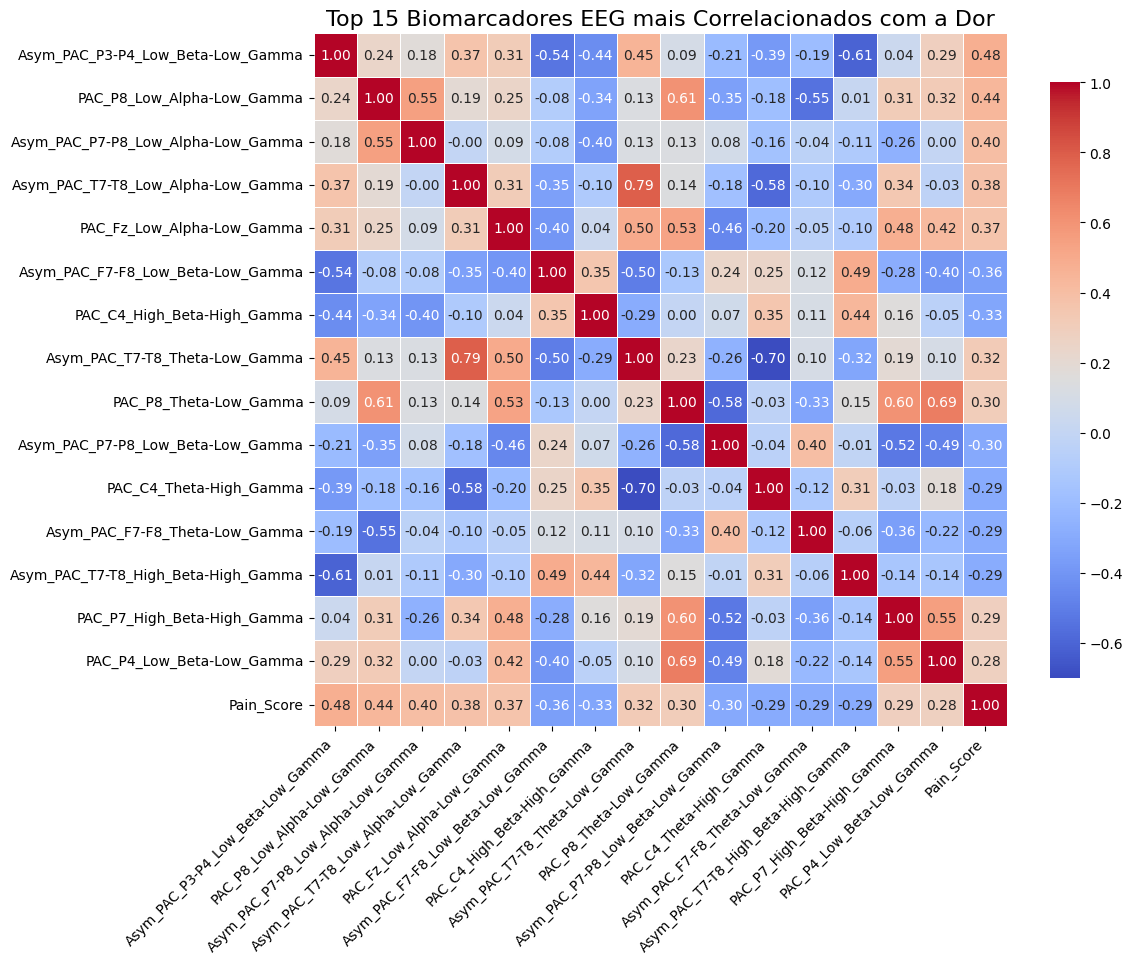

In [8]:
df_features = pd.DataFrame(X, columns=feature_names)
df_features['Pain_Score'] = y

correlations = df_features.corr()['Pain_Score'].drop('Pain_Score').abs().sort_values(ascending=False)
top_features = correlations.head(15).index.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_features[top_features + ['Pain_Score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, 
            cbar_kws={"shrink": .8}, linewidths=.5)

plt.title("Top 15 Biomarcadores EEG mais Correlacionados com a Dor", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Boxplots

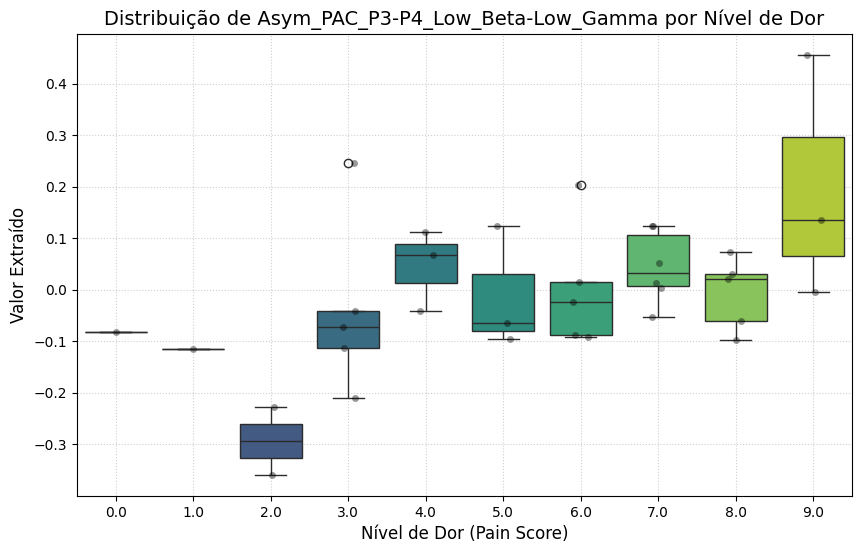

In [9]:
feature_alvo = top_features[0] 

plt.figure(figsize=(10, 6))
sns.boxplot(x='Pain_Score', y=feature_alvo, data=df_features, palette='viridis')
sns.stripplot(x='Pain_Score', y=feature_alvo, data=df_features, color='black', alpha=0.4)

plt.title(f'Distribuição de {feature_alvo} por Nível de Dor', fontsize=14)
plt.xlabel('Nível de Dor (Pain Score)', fontsize=12)
plt.ylabel('Valor Extraído', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()